In [ ]:
import os
import json
import shutil
import cv2
import numpy as np

from typing import List

def process_landmark_annotations(
    json_path: str,
    output_dir: str,
    images_dir: str,
    normalize: bool = False
) -> None:
    """
    Process JSON facial landmark annotations and create organized .txt files for each image.

    Args:
        json_path (str): Path to the JSON file containing the landmark annotations.
        output_dir (str): Path to the output directory where 'images' and 'labels' folders will be created.
        images_dir (str): Path to the directory containing the original images.
        normalize (bool): If True, normalize landmark coordinates with respect to the image dimensions.

    Returns:
        None
    """
    # Define the ordered list of 72 landmarks
    landmarks_order = [
        f"face_contour_{i}" for i in range(1, 18)
    ] + [
        f"right_eyebrow_{i}" for i in range(18, 23)
    ] + [
        f"left_eyebrow_{i}" for i in range(23, 28)
    ] + [
        f"nose_bridge_{i}" for i in range(28, 32)
    ] + [
        f"nose_base_{i}" for i in range(32, 37)
    ] + [
        f"right_eye_{i}" for i in range(37, 43)
    ] + [
        f"left_eye_{i}" for i in range(43, 49)
    ] + [
        f"outer_lip_{i}" for i in range(49, 61)
    ] + [
        f"inner_lip_{i}" for i in range(61, 69)
    ] + [
        "under_lip_69", "upper_chin70", "left_chin_71", "right_chin_72"
    ]

    # Create output directories
    images_output_dir = os.path.join(output_dir, "images")
    labels_output_dir = os.path.join(output_dir, "labels")
    os.makedirs(images_output_dir, exist_ok=True)
    os.makedirs(labels_output_dir, exist_ok=True)

    # Load the JSON annotations
    with open(json_path, 'r') as f:
        annotations = json.load(f)

    for annotation in annotations:
        # Extract image information
        image_path = annotation["image"].split("?d=")[-1]  # Clean up image path
        image_name = os.path.basename(image_path)
        original_width = annotation["landmarks"][0]["original_width"]
        original_height = annotation["landmarks"][0]["original_height"]

        # Initialize landmarks with NaN for each image
        landmarks_data = {key: (np.nan, np.nan) for key in landmarks_order}

        # Fill in available landmark data
        for landmark in annotation["landmarks"]:
            label = landmark["keypointlabels"][0]
            x, y = landmark["x"], landmark["y"]

            # Step 1: Ensure desnormalization from 0-100 to absolute pixel
            if 0 <= x <= 100 and 0 <= y <= 100:
                # Rescale x and y from [0, 100] to [0, original_width] and [0, original_height]
                x = (x / 100) * original_width
                y = (y / 100) * original_height

            # Step 2: Normalize if requested
            if normalize:
                x /= original_width
                y /= original_height

            # Convert to integer if not normalized
            if not normalize:
                x = int(round(x))
                y = int(round(y))

            landmarks_data[label] = (x, y)

        # Create a single line for this instance
        instance_line = " ".join(
            f"{x:.6f} {y:.6f}" if normalize else f"{x} {y}"
            if not (np.isnan(x) or np.isnan(y)) else "nan nan"
            for x, y in landmarks_data.values()
        )

        # Write the annotation to the .txt file
        txt_path = os.path.join(labels_output_dir, f"{os.path.splitext(image_name)[0]}.txt")
        with open(txt_path, 'w') as txt_file:
            txt_file.write(instance_line + "\n")

        # Copy image to output folder
        src_image_path = os.path.join(images_dir, image_name)
        dst_image_path = os.path.join(images_output_dir, image_name)
        if os.path.exists(src_image_path):
            shutil.copy(src_image_path, dst_image_path)
        else:
            print(f"Warning: Image {src_image_path} not found, skipping.")

    print(f"Processing complete. Output saved to {output_dir}.")




# Example usage
process_landmark_annotations(
    json_path="/Users/jocareher/Downloads/babyface_72_311.json",
    output_dir="/Users/jocareher/Downloads/baby_face_72_311",
    images_dir="/Users/jocareher/Downloads/under_construction_dataset/Hospital_del_Mar",
    normalize=False
)


Processing complete. Output saved to /Users/jocareher/Downloads/baby_face_72_311.


In [5]:
def load_landmarks_from_txt(file_path):
    """
    Lee landmarks desde un archivo .txt.
    Cada línea contiene pares x, y en secuencia, algunos pueden ser NaN.
    Devuelve un array de shape (N, 2) con N landmarks. 
    Los que sean NaN se dejan como np.nan.
    """
    if not os.path.exists(file_path) or os.stat(file_path).st_size == 0:
        return None

    with open(file_path, 'r') as f:
        line = f.readline().strip()
    
    coords = list(map(float, line.split()))
    
    if len(coords) % 2 != 0:
        print(f"Advertencia: el archivo {file_path} no tiene un número par de valores.")
        return None

    landmarks = np.array(coords).reshape(-1, 2)
    return landmarks

def draw_landmarks_on_image(image, landmarks, color=(0, 0, 255)):
    """
    Dibuja los landmarks sobre la imagen, ignorando los que tengan NaN.
    El tamaño del punto (radio) se ajusta según el tamaño de la imagen.
    """
    # Calcula un radio proporcional al tamaño de la imagen
    h, w = image.shape[:2]
    # Por ejemplo, tomar 1% del lado más corto como radio
    radius = max(1, int(min(h, w) * 0.005))
    thickness = -1  # -1 para un círculo relleno

    for (x, y) in landmarks:
        if not (np.isnan(x) or np.isnan(y)):
            cv2.circle(image, (int(round(x)), int(round(y))), radius, color, thickness)
    return image

def overlay_landmarks_on_images(image_dir, txt_dir, output_dir):
    """
    Recorre un directorio con imágenes, busca sus landmarks en el directorio txt_dir,
    dibuja los landmarks sobre la imagen y guarda el resultado en output_dir.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        txt_file = base_name + '.txt'

        img_path = os.path.join(image_dir, img_file)
        txt_path = os.path.join(txt_dir, txt_file)

        if not os.path.exists(txt_path):
            print(f"No se encontró el archivo de landmarks para {img_file}, se omite.")
            continue

        # Cargar imagen
        image = cv2.imread(img_path)
        if image is None:
            print(f"No se pudo cargar la imagen {img_path}, se omite.")
            continue

        # Cargar landmarks
        landmarks = load_landmarks_from_txt(txt_path)
        if landmarks is None:
            print(f"No se pudo cargar landmarks desde {txt_path}, se omite.")
            continue

        # Dibujar landmarks sobre la imagen
        image_with_landmarks = draw_landmarks_on_image(image, landmarks)

        # Guardar en el directorio de salida
        output_path = os.path.join(output_dir, img_file)
        cv2.imwrite(output_path, image_with_landmarks)
        print(f"Guardada la imagen con landmarks en {output_path}")

# Ejemplo de uso:
image_dir = "/Users/jocareher/Downloads/baby_face_72_311/images"
txt_dir = "/Users/jocareher/Downloads/baby_face_72_311/labels"
output_dir = "/Users/jocareher/Downloads/plots_babyface72_311"
overlay_landmarks_on_images(image_dir, txt_dir, output_dir)


Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_289.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_276.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_262.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_302.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_316.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_100.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_114.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_128.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_129.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bc

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable, List, Sequence, Tuple


def remap_visibility(visibility: int) -> int:
    """
    Remap landmark visibility labels from the original convention to the new one.

    Original convention:
        - 1: not visible
        - 2: visible

    New convention:
        - 0: not visible
        - 1: visible

    Args:
        visibility: Original visibility label.

    Returns:
        Remapped visibility label.

    Raises:
        ValueError: If the visibility label is not 1 or 2.
    """
    mapping = {1: 0, 2: 1}
    if visibility not in mapping:
        raise ValueError(
            f"Unexpected visibility label: {visibility}. Expected 1 or 2."
        )
    return mapping[visibility]


def parse_annotation_line(
    line: str,
    num_landmarks: int = 72,
) -> List[Tuple[float, float, int]]:
    """
    Parse a single annotation line and extract only landmark coordinates and visibility.

    Expected input format:
        class_idx cx cy w h x1 y1 v1 x2 y2 v2 ... xn yn vn

    Output format in memory:
        [(x1, y1, v1), (x2, y2, v2), ..., (xn, yn, vn)]

    Args:
        line: Raw annotation line from the input file.
        num_landmarks: Number of landmarks expected in the annotation.

    Returns:
        A list of tuples, each containing:
            - x coordinate (float)
            - y coordinate (float)
            - remapped visibility (int)

    Raises:
        ValueError: If the annotation length is inconsistent.
    """
    tokens = line.strip().split()
    if not tokens:
        return []

    expected_length = 5 + 3 * num_landmarks
    if len(tokens) != expected_length:
        raise ValueError(
            f"Invalid annotation length. Expected {expected_length} values, "
            f"but got {len(tokens)}. Line content: {line}"
        )

    landmark_tokens = tokens[5:]
    landmarks: List[Tuple[float, float, int]] = []

    for index in range(0, len(landmark_tokens), 3):
        x_coord = float(landmark_tokens[index])
        y_coord = float(landmark_tokens[index + 1])
        visibility = int(float(landmark_tokens[index + 2]))
        remapped = remap_visibility(visibility)
        landmarks.append((x_coord, y_coord, remapped))

    return landmarks


def format_landmarks_block(
    landmarks: Sequence[Tuple[float, float, int]],
    float_precision: int = 6,
) -> str:
    """
    Convert a list of landmarks into the target text block format.

    Output format:
        x1 y1 v1
        x2 y2 v2
        ...
        xn yn vn

    Args:
        landmarks: Sequence of landmark tuples (x, y, v).
        float_precision: Number of decimal places used for coordinates.

    Returns:
        A formatted text block for one face annotation.
    """
    lines = [
        f"{x:.{float_precision}f} {y:.{float_precision}f} {v}"
        for x, y, v in landmarks
    ]
    return "\n".join(lines)


def convert_label_file(
    input_file: Path,
    output_file: Path,
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
) -> None:
    """
    Convert a single label file from the original format to the new landmark-only format.

    If the input file contains multiple face annotations, each face is written as a
    separate block. By default, blocks are separated with one blank line.

    Args:
        input_file: Path to the original label file.
        output_file: Path where the converted label file will be written.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert a blank line between
            multiple face annotations in the same file.

    Returns:
        None
    """
    raw_lines = input_file.read_text(encoding="utf-8").splitlines()

    blocks: List[str] = []
    for raw_line in raw_lines:
        if not raw_line.strip():
            continue

        landmarks = parse_annotation_line(raw_line, num_landmarks=num_landmarks)
        if landmarks:
            blocks.append(
                format_landmarks_block(
                    landmarks=landmarks,
                    float_precision=float_precision,
                )
            )

    output_file.parent.mkdir(parents=True, exist_ok=True)

    separator = "\n\n" if separate_instances_with_blank_line else "\n"
    output_text = separator.join(blocks)

    if output_text:
        output_text += "\n"

    output_file.write_text(output_text, encoding="utf-8")


def convert_split_labels(
    split_dir: Path,
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
    output_labels_dirname: str | None = None,
) -> None:
    """
    Convert all label files inside one dataset split.

    Expected split structure:
        split_dir/
            images/
            labels/

    By default, the original files inside 'labels/' are overwritten.
    If 'output_labels_dirname' is provided, converted files are written into:
        split_dir / output_labels_dirname

    Args:
        split_dir: Path to one split directory, such as train, val, or test.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert blank lines between
            multiple face annotations in the same output file.
        output_labels_dirname: Optional new directory name for converted labels.
            If None, the original 'labels' directory is overwritten.

    Returns:
        None

    Raises:
        FileNotFoundError: If the labels directory does not exist.
    """
    input_labels_dir = split_dir / "labels"
    if not input_labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {input_labels_dir}")

    if output_labels_dirname is None:
        output_labels_dir = input_labels_dir
    else:
        output_labels_dir = split_dir / output_labels_dirname
        output_labels_dir.mkdir(parents=True, exist_ok=True)

    label_files = sorted(input_labels_dir.glob("*.txt"))

    for input_file in label_files:
        if output_labels_dir.resolve() == input_labels_dir.resolve():
            output_file = input_file
        else:
            output_file = output_labels_dir / input_file.name

        convert_label_file(
            input_file=input_file,
            output_file=output_file,
            num_landmarks=num_landmarks,
            float_precision=float_precision,
            separate_instances_with_blank_line=separate_instances_with_blank_line,
        )


def convert_dataset_labels(
    dataset_root: str | Path,
    splits: Sequence[str] = ("train", "val", "test"),
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
    output_labels_dirname: str | None = None,
) -> None:
    """
    Convert label files for all requested dataset splits.

    Expected dataset structure:
        dataset_root/
            train/
                images/
                labels/
            val/
                images/
                labels/
            test/
                images/
                labels/

    Args:
        dataset_root: Root directory of the dataset.
        splits: Split names to process.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert blank lines between
            multiple face annotations in the same output file.
        output_labels_dirname: Optional new directory name for converted labels.
            If None, original label files are overwritten.

    Returns:
        None
    """
    dataset_root = Path(dataset_root)

    for split_name in splits:
        split_dir = dataset_root / split_name
        convert_split_labels(
            split_dir=split_dir,
            num_landmarks=num_landmarks,
            float_precision=float_precision,
            separate_instances_with_blank_line=separate_instances_with_blank_line,
            output_labels_dirname=output_labels_dirname,
        )


def preview_converted_label(
    input_file: str | Path,
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
) -> str:
    """
    Preview how one label file would look after conversion without writing it to disk.

    Args:
        input_file: Path to the original label file.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert blank lines between
            multiple face annotations.

    Returns:
        Converted text content as a string.
    """
    input_file = Path(input_file)
    raw_lines = input_file.read_text(encoding="utf-8").splitlines()

    blocks: List[str] = []
    for raw_line in raw_lines:
        if not raw_line.strip():
            continue

        landmarks = parse_annotation_line(raw_line, num_landmarks=num_landmarks)
        if landmarks:
            blocks.append(
                format_landmarks_block(
                    landmarks=landmarks,
                    float_precision=float_precision,
                )
            )

    separator = "\n\n" if separate_instances_with_blank_line else "\n"
    return separator.join(blocks)

In [2]:
from pathlib import Path

sample_file = Path("/Users/jocareher/Documents/synthetic_lmks_vis_dataset/train/labels/synthetic_shape_00027_left.txt")
print(preview_converted_label(sample_file))

0.099518 0.411597 0
0.100589 0.406844 0
0.077582 0.390684 1
0.164259 0.401616 1
0.269663 0.388783 1
0.060995 0.604087 0
0.042804 0.573194 0
0.004815 0.563688 1
0.089353 0.575095 1
0.092028 0.605038 1
0.060460 0.612643 1
0.120920 0.729087 1
0.048154 0.685361 0
0.053505 0.690114 1
0.061530 0.685361 1
0.189941 0.737643 0
0.115035 0.782319 1
0.140717 0.815589 1
0.132691 0.904468 1
0.467095 0.552757 0
0.437667 0.680608 0
0.737293 0.568441 1
0.698234 0.727662 1
0.432317 0.745247 0
0.348315 0.792300 0
0.293740 0.824620 0
0.246656 0.857890 0
0.209738 0.895437 0
0.201177 0.921578 0
0.193151 0.975760 0
0.292670 0.944392 1
0.349385 0.930133 1
0.431247 0.904468 1
0.501338 0.878327 1
0.573034 0.847433 1
0.667202 0.801806 1
0.126271 0.400665 0
0.065811 0.352662 0
0.047084 0.314163 0
0.050294 0.307985 1
0.068486 0.347433 0
0.103264 0.341730 1
0.131086 0.290875 1
0.180310 0.288023 1
0.237025 0.322243 1
0.336544 0.376426 1
0.058855 0.465779 1
0.016586 0.511407 1
0.086142 0.373574 0
0.089888 0.371673 0


In [ ]:
convert_dataset_labels(
    dataset_root="/Users/jocareher/Documents/synthetic_lmks_vis_dataset",
    splits=("train", "val", "test"),
    num_landmarks=72,
    float_precision=6,
    separate_instances_with_blank_line=False,
    output_labels_dirname=None,
)

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import List, Sequence, Tuple

from PIL import Image, ImageDraw


Landmark = Tuple[float, float, int]
LandmarkInstance = List[Landmark]


def parse_yaw_label_header(raw_line: str) -> float | None:
    """Return yaw angle when a label first line is a one-value metadata header."""
    tokens = raw_line.split()
    if len(tokens) != 1:
        return None
    return float(tokens[0])


def parse_landmark_label_file(label_file: str | Path) -> List[LandmarkInstance]:
    """
    Parse a synthetic landmark annotation file.

    Supported formats:

    Current synthetic yaw format:
        yaw_angle
        x1 y1 v1
        x2 y2 v2
        ...
        x72 y72 v72

    Legacy format:
        x1 y1 v1
        x2 y2 v2
        ...

    If multiple legacy faces are present in the same file, they must be separated
    by a blank line. The yaw header is metadata only and is not returned as a
    landmark instance.
    """
    label_file = Path(label_file)
    raw_lines = label_file.read_text(encoding="utf-8").splitlines()
    non_empty_lines = [line.strip() for line in raw_lines if line.strip()]
    if not non_empty_lines:
        return []

    first_tokens = non_empty_lines[0].split()
    has_yaw_header = len(first_tokens) == 1
    if has_yaw_header:
        parse_yaw_label_header(non_empty_lines[0])

    lines = non_empty_lines[1:] if has_yaw_header else non_empty_lines
    instances: List[LandmarkInstance] = []
    current_instance: LandmarkInstance = []

    for line in lines:
        tokens = line.split()
        if len(tokens) != 3:
            raise ValueError(
                f"Invalid landmark line in {label_file}: '{line}'. "
                "Expected format: 'x y v'."
            )

        x_coord = float(tokens[0])
        y_coord = float(tokens[1])
        visibility = int(float(tokens[2]))

        if visibility not in (0, 1):
            raise ValueError(
                f"Invalid visibility value in {label_file}: {visibility}. "
                "Expected 0 or 1."
            )

        current_instance.append((x_coord, y_coord, visibility))

    if current_instance:
        instances.append(current_instance)

    return instances


def draw_landmarks_on_image(
    image: Image.Image,
    landmark_instances: Sequence[LandmarkInstance],
    point_radius: int = 3,
) -> Image.Image:
    """
    Draw landmarks on a copy of the input image.

    Visibility color convention:
        - 0: blue
        - 1: red

    Landmark coordinates are assumed to be normalized in [0, 1].
    """
    output_image = image.copy()
    drawer = ImageDraw.Draw(output_image)

    image_width, image_height = output_image.size

    for instance in landmark_instances:
        for x_norm, y_norm, visibility in instance:
            x_pixel = x_norm * image_width
            y_pixel = y_norm * image_height

            color = "blue" if visibility == 0 else "red"

            drawer.ellipse(
                (
                    x_pixel - point_radius,
                    y_pixel - point_radius,
                    x_pixel + point_radius,
                    y_pixel + point_radius,
                ),
                fill=color,
                outline=color,
            )

    return output_image


def find_image_for_label(
    label_file: str | Path,
    images_dir: str | Path,
    allowed_suffixes: Sequence[str] = (".jpg", ".jpeg", ".png", ".webp"),
) -> Path:
    """Find the corresponding image file for a given label file based on stem matching."""
    label_file = Path(label_file)
    images_dir = Path(images_dir)

    for suffix in allowed_suffixes:
        candidate = images_dir / f"{label_file.stem}{suffix}"
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"No matching image found for label file '{label_file.name}' in '{images_dir}'."
    )


def plot_single_label_on_image(
    image_file: str | Path,
    label_file: str | Path,
    output_file: str | Path,
    point_radius: int = 3,
) -> None:
    """Draw landmarks from one label file on its corresponding image and save the result."""
    image_file = Path(image_file)
    label_file = Path(label_file)
    output_file = Path(output_file)

    image = Image.open(image_file).convert("RGB")
    landmark_instances = parse_landmark_label_file(label_file)

    plotted_image = draw_landmarks_on_image(
        image=image,
        landmark_instances=landmark_instances,
        point_radius=point_radius,
    )

    output_file.parent.mkdir(parents=True, exist_ok=True)
    plotted_image.save(output_file)


def plot_split_landmarks(
    split_dir: str | Path,
    output_root: str | Path,
    point_radius: int = 3,
    allowed_suffixes: Sequence[str] = (".jpg", ".jpeg", ".png", ".webp"),
) -> None:
    """Plot landmarks for all samples in one dataset split and save the outputs."""
    split_dir = Path(split_dir)
    output_root = Path(output_root)

    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"
    output_dir = output_root / split_dir.name

    if not images_dir.exists():
        raise FileNotFoundError(f"Images directory not found: {images_dir}")

    if not labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {labels_dir}")

    label_files = sorted(labels_dir.glob("*.txt"))

    for label_file in label_files:
        image_file = find_image_for_label(
            label_file=label_file,
            images_dir=images_dir,
            allowed_suffixes=allowed_suffixes,
        )

        output_file = output_dir / f"{label_file.stem}.jpg"

        plot_single_label_on_image(
            image_file=image_file,
            label_file=label_file,
            output_file=output_file,
            point_radius=point_radius,
        )


def plot_dataset_landmarks(
    dataset_root: str | Path,
    output_root: str | Path = "plots",
    splits: Sequence[str] = ("train", "val", "test"),
    point_radius: int = 3,
    allowed_suffixes: Sequence[str] = (".jpg", ".jpeg", ".png", ".webp"),
) -> None:
    """Plot landmarks for all requested dataset splits and save the visualizations."""
    dataset_root = Path(dataset_root)

    for split_name in splits:
        split_dir = dataset_root / split_name
        plot_split_landmarks(
            split_dir=split_dir,
            output_root=output_root,
            point_radius=point_radius,
            allowed_suffixes=allowed_suffixes,
        )


In [6]:
from pathlib import Path

dataset_root = Path("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")

image_file = dataset_root / "train" / "images" / "synthetic_shape_00010_left.jpg"
label_file = dataset_root / "train" / "labels" / "synthetic_shape_00010_left.txt"
output_file = Path("plots/train/synthetic_shape_00010_left.jpg")

plot_single_label_on_image(
    image_file=image_file,
    label_file=label_file,
    output_file=output_file,
    point_radius=6,
)

In [ ]:
plot_dataset_landmarks(
    dataset_root="/Users/jocareher/Documents/synthetic_lmks_vis_dataset",
    output_root="/Users/jocareher/Documents/synthetic_lmks_vis_dataset/plots",
    splits=("train", "val", "test"),
    point_radius=6,
)

In [15]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import pandas as pd

def extract_rotation_from_filename(filename: str) -> str:
    """
    Extract yaw rotation category from a filename.

    Expected suffixes:
        frontal
        left
        quarter_left
        right
        quarter_right
    """

    name = Path(filename).stem

    rotations = [
        "quarter_left",
        "quarter_right",
        "frontal",
        "left",
        "right",
    ]

    for rot in rotations:
        if name.endswith(f"_{rot}"):
            return rot

    raise ValueError(f"Rotation not found in filename: {filename}")

def count_landmarks_visibility(label_file: Path) -> Tuple[int, int]:
    """
    Count visible and invisible landmarks in a label file.

    Args:
        label_file: Path to label file.

    Returns:
        Tuple:
            (visible_count, invisible_count)
    """
    visible = 0
    invisible = 0

    with open(label_file) as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            _, _, v = line.split()
            v = int(v)

            if v == 1:
                visible += 1
            elif v == 0:
                invisible += 1
            else:
                raise ValueError(f"Unexpected visibility value {v}")

    return visible, invisible

def analyze_split(split_dir: Path) -> pd.DataFrame:
    """
    Analyze one dataset split.

    Computes:
        - rotation
        - number of images
        - visible landmarks
        - invisible landmarks

    Args:
        split_dir: Path to split directory (train/val/test).

    Returns:
        Pandas DataFrame with per-image statistics.
    """
    labels_dir = split_dir / "labels"

    rows = []

    for label_file in sorted(labels_dir.glob("*.txt")):

        rotation = extract_rotation_from_filename(label_file.name)

        visible, invisible = count_landmarks_visibility(label_file)

        rows.append(
            {
                "split": split_dir.name,
                "rotation": rotation,
                "visible_landmarks": visible,
                "invisible_landmarks": invisible,
            }
        )

    df = pd.DataFrame(rows)

    return df

def analyze_dataset(dataset_root: str | Path) -> pd.DataFrame:
    """
    Analyze full dataset (train/val/test).

    Args:
        dataset_root: Root dataset directory.

    Returns:
        DataFrame with per-image statistics.
    """
    dataset_root = Path(dataset_root)

    dfs = []

    for split in ["train", "val", "test"]:
        split_dir = dataset_root / split
        df_split = analyze_split(split_dir)
        dfs.append(df_split)

    return pd.concat(dfs, ignore_index=True)

In [16]:
df = analyze_dataset("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")

In [17]:
df

,split,rotation,visible_landmarks,invisible_landmarks
0,train,frontal,61,11
1,train,quarter_left,60,12
2,train,frontal,61,11
3,train,left,36,36
4,train,quarter_left,59,13
...,...,...,...,...
9965,test,quarter_left,60,12
9966,test,frontal,61,11
9967,test,right,46,26
9968,test,frontal,62,10


In [18]:
images_per_rotation = (
    df.groupby(["split", "rotation"])
    .size()
    .reset_index(name="num_images")
)

images_per_rotation

,split,rotation,num_images
0,test,frontal,200
1,test,left,201
2,test,quarter_left,201
3,test,quarter_right,201
4,test,right,199
5,train,frontal,1600
6,train,left,1596
7,train,quarter_left,1598
8,train,quarter_right,1598
9,train,right,1582


In [19]:
landmark_stats = (
    df.groupby(["split", "rotation"])[
        ["visible_landmarks", "invisible_landmarks"]
    ]
    .sum()
    .reset_index()
)

landmark_stats

,split,rotation,visible_landmarks,invisible_landmarks
0,test,frontal,12185,2215
1,test,left,8435,6037
2,test,quarter_left,12081,2391
3,test,quarter_right,12121,2351
4,test,right,8120,6208
5,train,frontal,97487,17713
6,train,left,66563,48349
7,train,quarter_left,96037,19019
8,train,quarter_right,95921,19135
9,train,right,64751,49153


In [20]:
import numpy as np
from pathlib import Path


def visibility_per_landmark(dataset_root):

    counts_visible = np.zeros(72)
    counts_total = np.zeros(72)

    for split in ["train", "val", "test"]:

        labels_dir = Path(dataset_root) / split / "labels"

        for file in labels_dir.glob("*.txt"):

            with open(file) as f:
                lines = [l.strip() for l in f if l.strip()]

            for i, line in enumerate(lines):
                _, _, v = line.split()
                v = int(v)

                counts_total[i] += 1
                counts_visible[i] += v

    visibility = counts_visible / counts_total

    return visibility

In [25]:
visibility_per_landmark = visibility_per_landmark("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")

In [28]:
visibility_per_landmark

array([0.78134403, 0.76459378, 1.        , 0.74674022, 0.77191575,
       0.80220662, 0.5997994 , 1.        , 0.60170512, 0.79267803,
       0.99929789, 0.73891675, 0.92306921, 0.9996991 , 0.90631896,
       0.7327984 , 0.84122367, 0.86890672, 0.99889669, 0.41043129,
       0.40561685, 0.40682046, 0.40561685, 0.40441324, 0.40952859,
       0.4112337 , 0.50541625, 0.59849549, 0.63510532, 0.69458375,
       0.63660983, 0.611334  , 0.53209629, 0.41203611, 0.40882648,
       0.40230692, 0.61334002, 0.78635908, 0.82397192, 0.85987964,
       0.80792377, 0.80541625, 0.84744233, 0.8219659 , 0.78726179,
       0.61955868, 0.99819458, 0.99087262, 0.82477432, 0.81995988,
       0.80130391, 0.8005015 , 0.81745236, 0.82016048, 0.80260782,
       0.79679037, 0.80300903, 0.79709127, 0.78375125, 0.79047141,
       0.80481444, 0.79017051, 0.73771314, 0.66920762, 0.63229689,
       0.61364092, 0.7338014 , 0.90982949, 0.96409228, 0.92808425,
       0.70060181, 0.70892678])

In [21]:
import numpy as np


all_x = []
all_y = []

for split in ["train","val","test"]:

    labels_dir = Path(dataset_root)/split/"labels"

    for file in labels_dir.glob("*.txt"):

        with open(file) as f:

            for line in f:
                if not line.strip():
                    continue

                x,y,v = line.split()

                all_x.append(float(x))
                all_y.append(float(y))

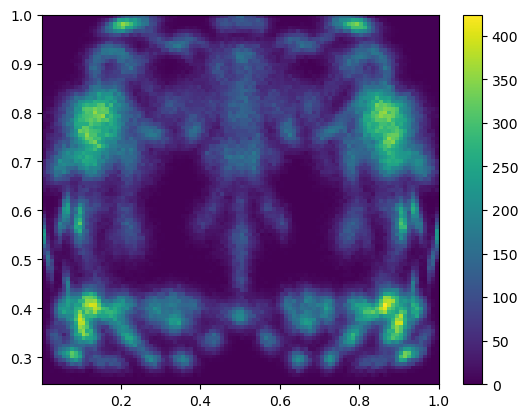

In [22]:
import matplotlib.pyplot as plt

plt.hist2d(all_x, all_y, bins=100)
plt.colorbar()
plt.show()

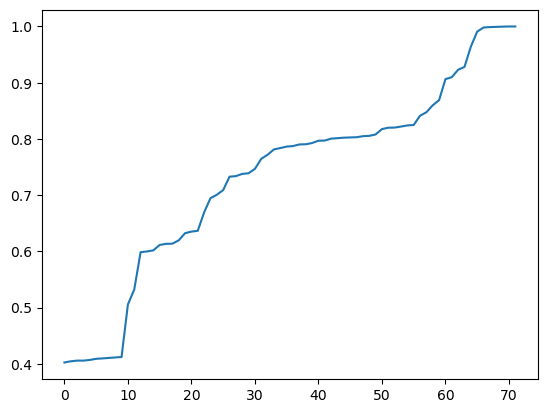

In [29]:
plt.plot(sorted(visibility_per_landmark))

In [23]:
widths = []
heights = []

for file in labels_dir.glob("*.txt"):

    xs = []
    ys = []

    with open(file) as f:

        for line in f:
            if not line.strip():
                continue

            x,y,v = line.split()

            xs.append(float(x))
            ys.append(float(y))

    widths.append(max(xs)-min(xs))
    heights.append(max(ys)-min(ys))

(array([  5.,  28.,  44., 136., 222., 246., 180., 108.,  30.,   3.]),
 array([0.631422 , 0.6425071, 0.6535922, 0.6646773, 0.6757624, 0.6868475,
        0.6979326, 0.7090177, 0.7201028, 0.7311879, 0.742273 ]),
 <BarContainer object of 10 artists>)

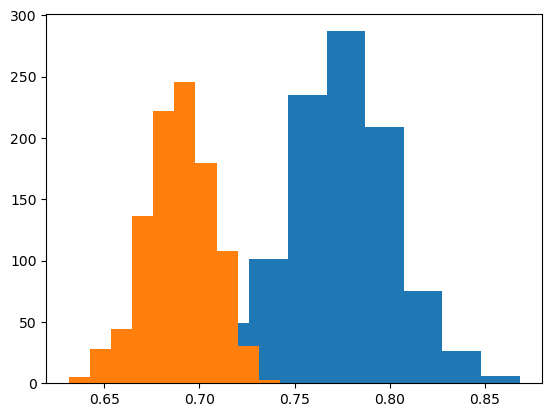

In [24]:
plt.hist(widths)
plt.hist(heights)

(array([  1.,  17.,  58., 169., 270., 270., 142.,  49.,  19.,   7.]),
 array([0.93537846, 0.97326741, 1.01115636, 1.04904531, 1.08693426,
        1.12482321, 1.16271216, 1.20060111, 1.23849006, 1.27637901,
        1.31426796]),
 <BarContainer object of 10 artists>)

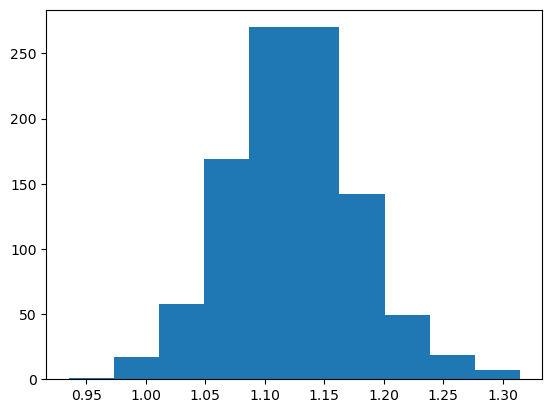

In [30]:
ratio = np.array(widths) / np.array(heights)
plt.hist(ratio)

In [32]:
from __future__ import annotations

from pathlib import Path
from typing import List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def load_shape_vector_from_label_file(
    label_file: str | Path,
) -> np.ndarray:
    """
    Load a landmark annotation file and convert it into a flattened shape vector.

    The expected label format is:
        x y v
        x y v
        ...
    with one face per file.

    Only x and y coordinates are used. Visibility is ignored for PCA.

    Args:
        label_file: Path to the label file.

    Returns:
        A NumPy array of shape (144,), corresponding to 72 landmarks with
        flattened x and y coordinates.

    Raises:
        ValueError: If the file contains zero or multiple face instances.
    """
    instances = parse_landmark_label_file(label_file)

    if len(instances) != 1:
        raise ValueError(
            f"Expected exactly one face instance in {label_file}, "
            f"but found {len(instances)}."
        )

    landmarks = instances[0]
    coords: List[float] = []

    for x_coord, y_coord, _ in landmarks:
        coords.extend([x_coord, y_coord])

    return np.asarray(coords, dtype=np.float32)

def build_pca_dataframe(
    dataset_root: str | Path,
    splits: Sequence[str] = ("train", "val", "test"),
) -> pd.DataFrame:
    """
    Build a DataFrame containing flattened landmark coordinates and metadata.

    Args:
        dataset_root: Root directory of the dataset.
        splits: Dataset splits to include.

    Returns:
        A DataFrame with metadata columns:
            - split
            - filename
            - rotation
        and 144 feature columns:
            - f_000 ... f_143
    """
    dataset_root = Path(dataset_root)
    rows = []

    for split_name in splits:
        labels_dir = dataset_root / split_name / "labels"

        for label_file in sorted(labels_dir.glob("*.txt")):
            shape_vector = load_shape_vector_from_label_file(label_file)
            rotation = extract_rotation_from_filename(label_file.name)

            row = {
                "split": split_name,
                "filename": label_file.stem,
                "rotation": rotation,
            }

            for index, value in enumerate(shape_vector):
                row[f"f_{index:03d}"] = float(value)

            rows.append(row)

    return pd.DataFrame(rows)

def run_shape_pca(
    df_shapes: pd.DataFrame,
    n_components: int = 10,
) -> Tuple[pd.DataFrame, PCA]:
    """
    Run PCA on flattened landmark coordinates.

    Args:
        df_shapes: DataFrame returned by build_pca_dataframe.
        n_components: Number of principal components.

    Returns:
        A tuple containing:
            - DataFrame with metadata and PCA projections
            - Fitted PCA object
    """
    feature_columns = [col for col in df_shapes.columns if col.startswith("f_")]
    x_matrix = df_shapes[feature_columns].to_numpy(dtype=np.float32)

    pca = PCA(n_components=n_components)
    transformed = pca.fit_transform(x_matrix)

    df_pca = df_shapes[["split", "filename", "rotation"]].copy()

    for index in range(n_components):
        df_pca[f"PC{index + 1}"] = transformed[:, index]

    return df_pca, pca


def plot_pca_scatter(
    df_pca: pd.DataFrame,
    x_component: str = "PC1",
    y_component: str = "PC2",
    color_by: str = "rotation",
    figsize: Tuple[int, int] = (8, 6),
) -> None:
    """
    Plot a 2D PCA scatter plot colored by a metadata column.

    Args:
        df_pca: DataFrame returned by run_shape_pca.
        x_component: Column name for x-axis.
        y_component: Column name for y-axis.
        color_by: Metadata column used for color grouping.
        figsize: Figure size.

    Returns:
        None
    """
    plt.figure(figsize=figsize)

    for group_value in sorted(df_pca[color_by].unique()):
        subset = df_pca[df_pca[color_by] == group_value]
        plt.scatter(
            subset[x_component],
            subset[y_component],
            label=group_value,
            alpha=0.65,
            s=18,
        )

    plt.xlabel(x_component)
    plt.ylabel(y_component)
    plt.title(f"{x_component} vs {y_component} colored by {color_by}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_explained_variance(
    pca: PCA,
    figsize: Tuple[int, int] = (8, 4),
) -> None:
    """
    Plot explained variance ratio and cumulative explained variance.

    Args:
        pca: Fitted PCA object.
        figsize: Figure size.

    Returns:
        None
    """
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    x_axis = np.arange(1, len(explained) + 1)

    plt.figure(figsize=figsize)
    plt.plot(x_axis, explained, marker="o", label="Explained variance ratio")
    plt.plot(x_axis, cumulative, marker="o", label="Cumulative explained variance")
    plt.xlabel("Principal component")
    plt.ylabel("Variance ratio")
    plt.title("PCA explained variance")
    plt.xticks(x_axis)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

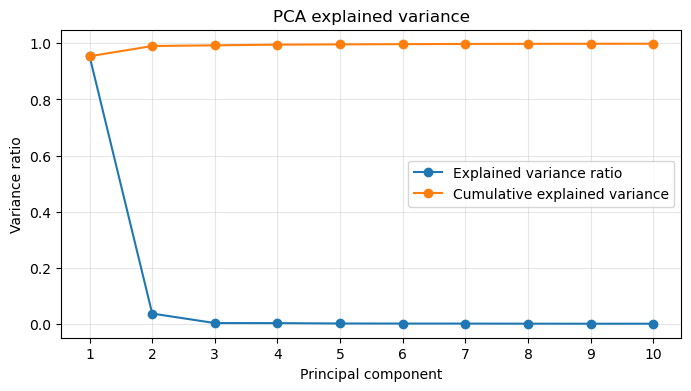

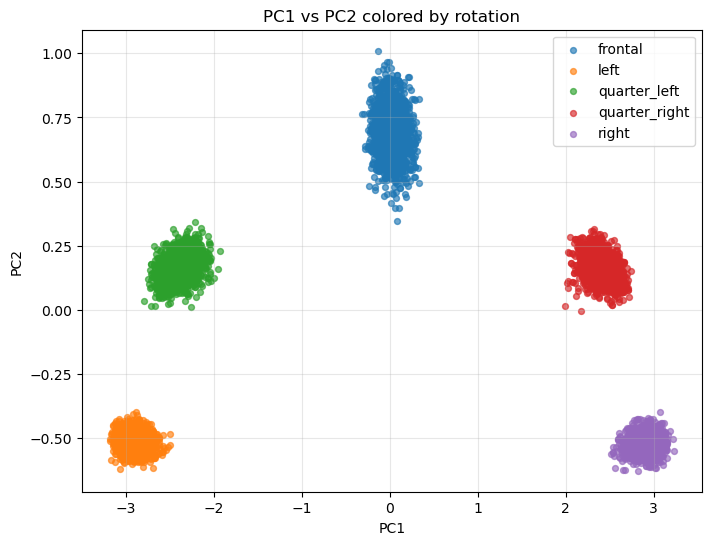

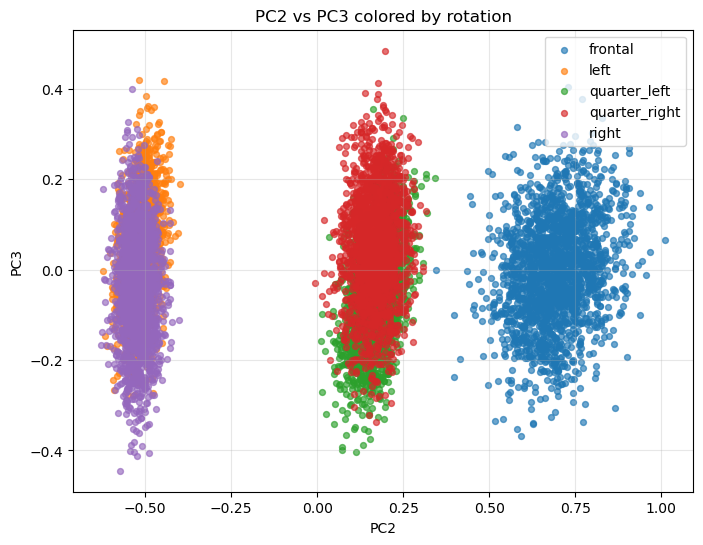

In [33]:
df_shapes = build_pca_dataframe("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")
df_pca, pca = run_shape_pca(df_shapes, n_components=10)

plot_explained_variance(pca)
plot_pca_scatter(df_pca, x_component="PC1", y_component="PC2", color_by="rotation")
plot_pca_scatter(df_pca, x_component="PC2", y_component="PC3", color_by="rotation")

In [ ]:
from pathlib import Path
from typing import List, Tuple, Optional

import cv2
import numpy as np
import matplotlib.pyplot as plt


def read_synthetic_yaw_label(keypoints_file: str | Path) -> tuple[float | None, List[Tuple[float, float, int]]]:
    """Read a synthetic label file with optional first-line yaw metadata."""
    keypoints_file = Path(keypoints_file)
    lines = [line.strip() for line in keypoints_file.read_text(encoding="utf-8").splitlines() if line.strip()]
    if not lines:
        return None, []

    yaw_angle: float | None = None
    first_tokens = lines[0].split()
    landmark_lines = lines
    if len(first_tokens) == 1:
        yaw_angle = float(first_tokens[0])
        landmark_lines = lines[1:]

    keypoints: List[Tuple[float, float, int]] = []
    for line in landmark_lines:
        tokens = line.split()
        if len(tokens) != 3:
            raise ValueError(f"Expected 'x y v' landmark row in {keypoints_file}, got: {line!r}")
        x, y, v = tokens
        keypoints.append((float(x), float(y), int(float(v))))

    return yaw_angle, keypoints


def plot_landmarks(
    image_path: str,
    keypoints_file: str,
    output_image_path: Optional[str] = None,
    show_names: bool = True,
    point_size: int = 40,
    font_size: int = 10,
):
    """
    Plot facial landmarks on an image using the current synthetic dataset format.

    Expected label format:
        yaw_angle
        x y v
        x y v
        ...

    The yaw angle is metadata only. Legacy files without the yaw header are also accepted.
    """

    landmark_names = [
        'exR','enR','n','enL','exL','acR','aR','prn','aL','acL','sn',
        'chR','cphR','ls','cphL','chL','li','sl','pg','tR','oiR','tL','oiL',
        'faceO_23','faceO_24','faceO_25','faceO_26','faceO_27',
        'faceO_28','chin_29','faceO_30','faceO_31','faceO_32',
        'faceO_33','faceO_34','faceO_35','rightEB_36','rightEB_37',
        'rightEB_38','rightEB_39','rightEB_40','leftEB_41',
        'leftEB_42','leftEB_43','leftEB_44','leftEB_45','nose_46',
        'nose_47','rightE_48','rightE_49','rightE_50','rightE_51','leftE_52',
        'leftE_53','leftE_54','leftE_55','upperL_56','upperL_57','lowerL_58',
        'lowerL_59','lowerL_60','lowerL_61','lipE_62','upperL_63','upperL_64',
        'upperL_65','lipE_66','lowerL_67','lowerL_68','lowerL_69','chin_70','chin_71'
    ]

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]
    yaw_angle, keypoints = read_synthetic_yaw_label(keypoints_file)

    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)

    for idx, (x, y, vis) in enumerate(keypoints):
        x_pixel = int(x * w)
        y_pixel = int(y * h)
        color = "red" if vis == 1 else "blue"
        plt.scatter(x_pixel, y_pixel, color=color, s=point_size)

        label = landmark_names[idx] if show_names and idx < len(landmark_names) else str(idx)
        offset = 1
        plt.text(
            x_pixel + offset,
            y_pixel - offset,
            label,
            fontsize=font_size,
            color="black",
            fontweight="bold",
        )

    title = "Landmarks with Names" if show_names else "Landmarks with Indices"
    if yaw_angle is not None:
        yaw_text = f"{int(yaw_angle):+d}°" if float(yaw_angle).is_integer() and yaw_angle > 0 else f"{yaw_angle:g}°"
        title = f"{title} | yaw {yaw_text}"

    plt.title(title)
    plt.axis("off")

    if output_image_path:
        plt.savefig(output_image_path, bbox_inches="tight")

    plt.show()


In [ ]:
plot_landmarks("/Users/jocareher/Documents/synthetic_lmks_vis_dataset/train/images/synthetic_shape_00016_frontal.jpg", "/Users/jocareher/Documents/synthetic_lmks_vis_dataset/train/labels/synthetic_shape_00016_frontal.txt", show_names=False)

In [57]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


def run_pose_specific_pca(df_shapes, rotation, n_components=10):
    """
    Run PCA for a specific head pose.

    Args:
        df_shapes: DataFrame returned by build_pca_dataframe.
        rotation: Pose to analyze (frontal, left, right, quarter_left, quarter_right).
        n_components: Number of PCA components.

    Returns:
        fitted PCA object
    """

    df_pose = df_shapes[df_shapes["rotation"] == rotation]

    feature_cols = [c for c in df_pose.columns if c.startswith("f_")]

    X = df_pose[feature_cols].to_numpy()

    pca = PCA(n_components=n_components)
    pca.fit(X)

    return pca

def plot_pose_specific_variance(pca, title):

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    x = np.arange(1, len(explained) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(x, explained, marker='o', label="explained")
    plt.plot(x, cumulative, marker='o', label="cumulative")

    plt.xlabel("component")
    plt.ylabel("variance")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

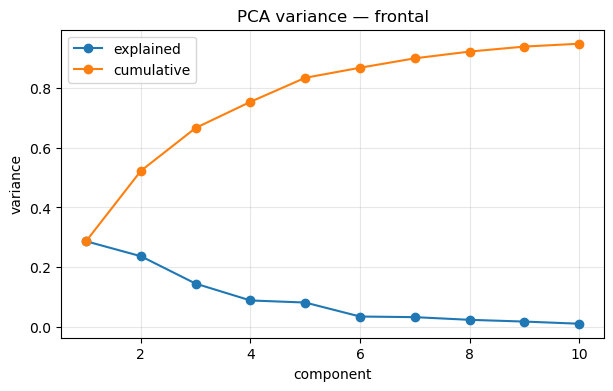

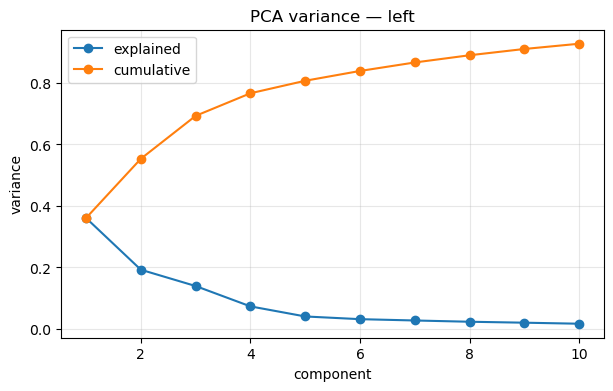

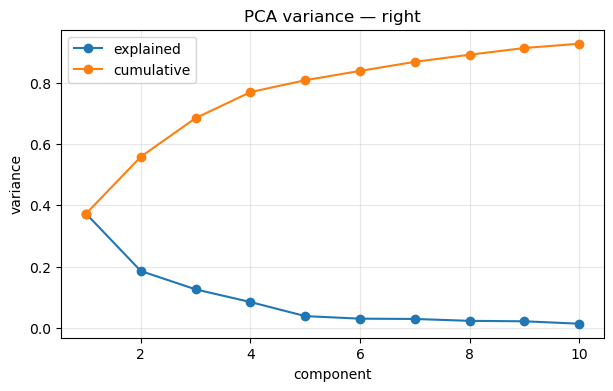

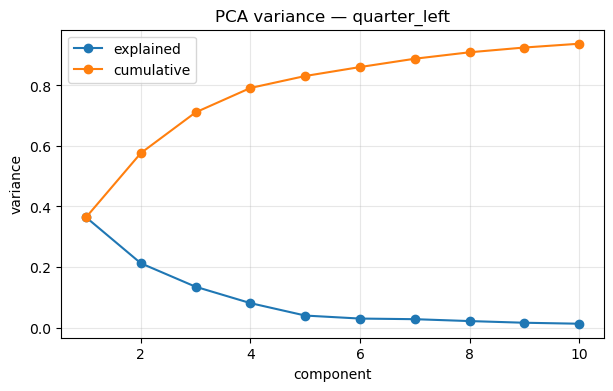

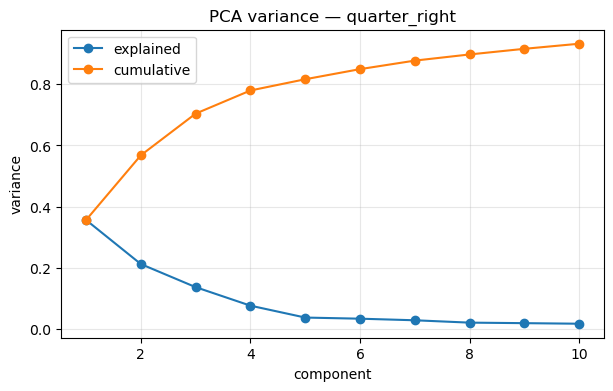

In [58]:
poses = ["frontal","left","right","quarter_left","quarter_right"]

for pose in poses:

    pca_pose = run_pose_specific_pca(df_shapes, pose)

    plot_pose_specific_variance(
        pca_pose,
        f"PCA variance — {pose}"
    )

In [71]:
def visualize_eigenshape(pca, component_index=0, scale=2.0):
    """
    Visualize PCA landmark modes using three panels:
    mean shape, positive deformation, negative deformation.

    Args:
        pca: fitted PCA object
        component_index: PCA component to visualize
        scale: deformation scale factor
    """

    mean_shape = pca.mean_.reshape(-1, 2)
    eigenvec = pca.components_[component_index].reshape(-1, 2)

    shape_plus = mean_shape + scale * eigenvec
    shape_minus = mean_shape - scale * eigenvec

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    shapes = [shape_minus, mean_shape, shape_plus]
    titles = ["- Mode", "Mean shape", "+ Mode"]
    colors = ["red", "black", "blue"]

    for ax, shape, title, color in zip(axes, shapes, titles, colors):

        ax.scatter(shape[:, 0], shape[:, 1], c=color, s=20)

        ax.set_title(title)
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.grid(alpha=0.3)

    plt.suptitle(f"PCA Mode {component_index + 1}")
    plt.tight_layout()

    plt.show()

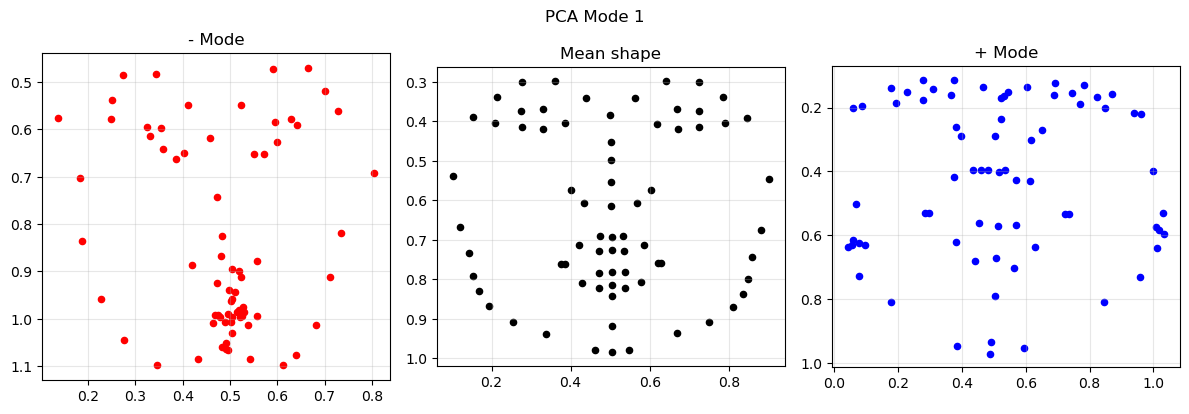

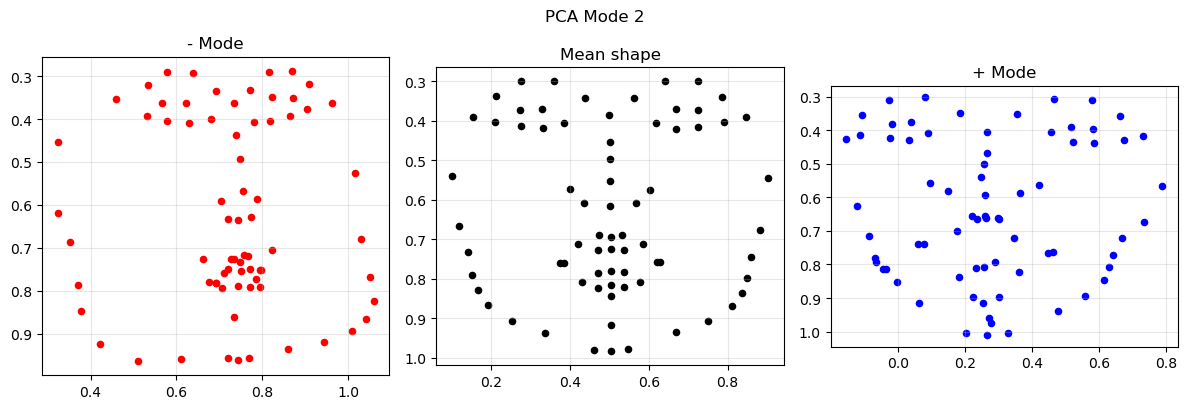

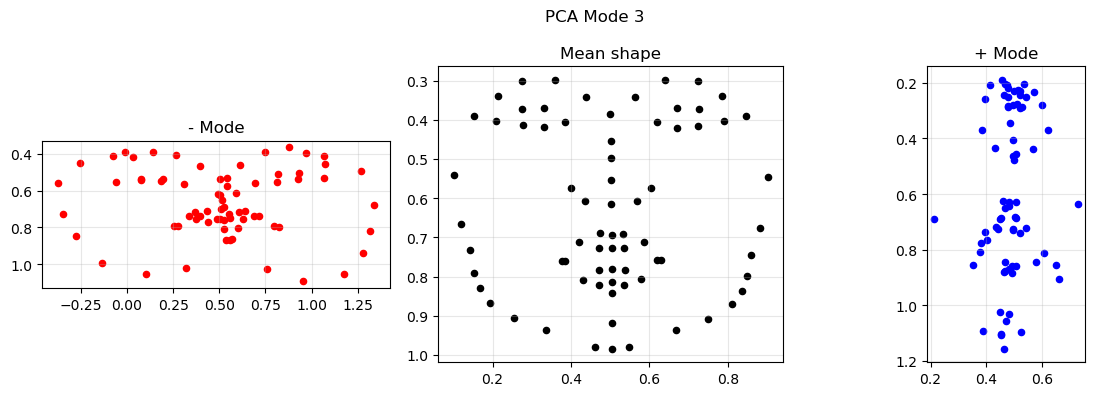

In [72]:
pca_frontal = run_pose_specific_pca(df_shapes,"frontal")

visualize_eigenshape(pca_frontal,0)
visualize_eigenshape(pca_frontal,1)
visualize_eigenshape(pca_frontal,2)

In [ ]:
from __future__ import annotations

import shutil
from pathlib import Path
from typing import Iterable, List

import numpy as np


REORDER_INDICES: List[int] = [
    19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 22, 21,
    36, 37, 38, 39, 40,
    41, 42, 43, 44, 45,
    2, 46, 47, 7,
    6, 5, 10, 9, 8,
    0, 48, 49, 1, 50, 51,
    3, 52, 53, 4, 54, 55,
    11, 56, 12, 13, 14, 57, 15, 58, 59, 16, 60, 61,
    62, 63, 64, 65, 66, 67, 68, 69,
    17, 18, 71, 70,
]


def load_landmark_file(label_path: Path) -> np.ndarray:
    """
    Load a landmark label file with shape (72, 3), where each row is:
    x y visibility.

    Parameters
    ----------
    label_path : Path
        Path to the landmark label file.

    Returns
    -------
    np.ndarray
        Array of shape (72, 3) with dtype float.

    Raises
    ------
    ValueError
        If the file does not contain exactly 72 rows and 3 columns.
    """
    points = np.loadtxt(label_path, dtype=float)

    if points.ndim == 1:
        points = points.reshape(1, -1)

    if points.shape != (72, 3):
        raise ValueError(
            f"Unexpected shape in '{label_path}'. "
            f"Expected (72, 3), got {points.shape}."
        )

    return points


def reorder_landmarks(points: np.ndarray, reorder_indices: List[int]) -> np.ndarray:
    """
    Reorder landmark rows according to a fixed permutation.

    Parameters
    ----------
    points : np.ndarray
        Landmark array with shape (72, 3).
    reorder_indices : List[int]
        Desired order. The i-th output row will be taken from
        points[reorder_indices[i]].

    Returns
    -------
    np.ndarray
        Reordered landmark array with shape (72, 3).
    """
    if points.shape != (72, 3):
        raise ValueError(f"Expected points with shape (72, 3), got {points.shape}.")

    if len(reorder_indices) != 72:
        raise ValueError(
            f"Expected 72 reorder indices, got {len(reorder_indices)}."
        )

    return points[reorder_indices]


def save_landmark_file(points: np.ndarray, output_path: Path) -> None:
    """
    Save reordered landmarks to disk.

    Parameters
    ----------
    points : np.ndarray
        Landmark array with shape (72, 3).
    output_path : Path
        Destination file path.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savetxt(output_path, points, fmt="%.8f %.8f %.0f")


def copy_images_directory(source_dir: Path, target_dir: Path) -> None:
    """
    Copy an images directory to the target location.

    Parameters
    ----------
    source_dir : Path
        Source images directory.
    target_dir : Path
        Destination images directory.
    """
    if target_dir.exists():
        shutil.rmtree(target_dir)

    shutil.copytree(source_dir, target_dir)


def process_split(
    input_root: Path,
    output_root: Path,
    split_name: str,
    reorder_indices: List[int],
) -> None:
    """
    Reorder all label files for a dataset split and copy images unchanged.

    Parameters
    ----------
    input_root : Path
        Root path of the original synthetic dataset.
    output_root : Path
        Root path where the reordered dataset will be saved.
    split_name : str
        Dataset split name. Expected values: 'train', 'val', or 'test'.
    reorder_indices : List[int]
        Landmark permutation to apply.
    """
    input_images_dir = input_root / split_name / "images"
    input_labels_dir = input_root / split_name / "labels"

    output_images_dir = output_root / split_name / "images"
    output_labels_dir = output_root / split_name / "labels"

    if not input_images_dir.exists():
        raise FileNotFoundError(f"Missing images directory: {input_images_dir}")

    if not input_labels_dir.exists():
        raise FileNotFoundError(f"Missing labels directory: {input_labels_dir}")

    copy_images_directory(input_images_dir, output_images_dir)
    output_labels_dir.mkdir(parents=True, exist_ok=True)

    label_files = sorted(input_labels_dir.glob("*.txt"))

    if not label_files:
        raise FileNotFoundError(f"No label files found in: {input_labels_dir}")

    for label_path in label_files:
        points = load_landmark_file(label_path)
        reordered_points = reorder_landmarks(points, reorder_indices)

        output_label_path = output_labels_dir / label_path.name
        save_landmark_file(reordered_points, output_label_path)

    print(f"[DONE] Processed split: {split_name} | files: {len(label_files)}")


def copy_optional_root_files(input_root: Path, output_root: Path) -> None:
    """
    Copy optional root-level files that are not modified by the reordering.

    Parameters
    ----------
    input_root : Path
        Original dataset root.
    output_root : Path
        Reordered dataset root.
    """
    optional_files = [
        "landmark_visibility_analysis.csv",
    ]

    for filename in optional_files:
        source_path = input_root / filename
        target_path = output_root / filename

        if source_path.exists():
            shutil.copy2(source_path, target_path)


def reorder_dataset(input_dataset_root: str, output_dataset_root: str) -> None:
    """
    Reorder all landmark labels in the synthetic dataset to match the MULTI-PIE
    landmark convention.

    Parameters
    ----------
    input_dataset_root : str
        Path to the original synthetic dataset root.
    output_dataset_root : str
        Path where the reordered dataset will be created.
    """
    input_root = Path(input_dataset_root)
    output_root = Path(output_dataset_root)

    if not input_root.exists():
        raise FileNotFoundError(f"Input dataset root does not exist: {input_root}")

    output_root.mkdir(parents=True, exist_ok=True)

    copy_optional_root_files(input_root, output_root)

    for split_name in ("train", "val", "test"):
        process_split(
            input_root=input_root,
            output_root=output_root,
            split_name=split_name,
            reorder_indices=REORDER_INDICES,
        )

    print(f"\nReordered dataset saved to: {output_root.resolve()}")


reorder_dataset(
    input_dataset_root="/path/to/your/synthetic_dataset",
    output_dataset_root="/path/to/your/synthetic_dataset_multipie_reordered",
)

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import numpy as np
from PIL import Image, ImageDraw


VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def format_yaw_angle_for_plot(yaw_angle: float | None) -> str:
    """Format yaw metadata for overlay text."""
    if yaw_angle is None:
        return "yaw: unknown"
    yaw_value = float(yaw_angle)
    if yaw_value.is_integer():
        yaw_text = f"{int(yaw_value):+d}" if yaw_value > 0 else f"{int(yaw_value):d}"
    else:
        yaw_text = f"{yaw_value:+g}" if yaw_value > 0 else f"{yaw_value:g}"
    return f"yaw: {yaw_text}°"


def get_landmark_connection_definitions() -> list[tuple[range, bool]]:
    """Return landmark index groups and whether they should be drawn as closed loops."""
    return [
        (range(0, 17), False),
        (range(17, 22), False),
        (range(22, 27), False),
        (range(27, 31), False),
        (range(31, 36), False),
        (range(36, 42), True),
        (range(42, 48), True),
        (range(48, 60), True),
        (range(60, 68), True),
        (range(68, 69), False),
        (range(69, 70), False),
        (range(70, 71), False),
        (range(71, 72), False),
    ]


def load_landmark_label(
    label_path: Path,
) -> tuple[np.ndarray, np.ndarray, float | None]:
    """
    Load landmark coordinates, visibility values, and optional yaw metadata.

    Current synthetic label format:
        yaw_angle
        x1 y1 v1
        ...
        x72 y72 v72

    Legacy files without the yaw header are also accepted.
    """
    label_path = Path(label_path)
    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    if not lines:
        raise ValueError(f"Empty label file: {label_path}")

    yaw_angle: float | None = None
    first_tokens = lines[0].split()
    landmark_lines = lines
    if len(first_tokens) == 1:
        yaw_angle = float(first_tokens[0])
        landmark_lines = lines[1:]

    rows: list[list[float]] = []
    for line_number, line in enumerate(landmark_lines, start=(2 if yaw_angle is not None else 1)):
        tokens = line.split()
        if len(tokens) != 3:
            raise ValueError(
                f"Invalid landmark row in '{label_path}' at line {line_number}. "
                f"Expected 'x y v', got: {line!r}."
            )
        rows.append([float(token) for token in tokens])

    data = np.asarray(rows, dtype=np.float32)
    if data.ndim != 2 or data.shape[1] != 3:
        raise ValueError(
            f"Invalid label format in '{label_path}'. "
            f"Expected shape (N, 3) after optional yaw header, got {data.shape}."
        )

    landmarks = data[:, :2].astype(np.float32, copy=True)
    visibility = data[:, 2].astype(np.int64, copy=True)

    return landmarks, visibility, yaw_angle


def draw_landmarks_on_image(
    image: Image.Image,
    landmarks: np.ndarray,
    visibility: np.ndarray,
    yaw_angle: float | None = None,
    point_radius: int = 4,
    show_indices: bool = False,
    show_yaw: bool = True,
    line_width: int = 10,
) -> Image.Image:
    """Draw landmarks, connections, and optional yaw metadata on a PIL image."""
    output_image = image.copy()
    draw = ImageDraw.Draw(output_image)

    image_width, image_height = output_image.size

    pixel_landmarks = np.zeros_like(landmarks, dtype=np.float32)
    pixel_landmarks[:, 0] = landmarks[:, 0] * image_width
    pixel_landmarks[:, 1] = landmarks[:, 1] * image_height

    line_color = "#A9A9A9"

    for index_range, is_closed in get_landmark_connection_definitions():
        indices = [index for index in index_range if index < len(pixel_landmarks)]
        for index_a, index_b in zip(indices[:-1], indices[1:]):
            point_a = tuple(pixel_landmarks[index_a])
            point_b = tuple(pixel_landmarks[index_b])
            draw.line([point_a, point_b], fill=line_color, width=line_width)

        if is_closed and len(indices) > 2:
            point_a = tuple(pixel_landmarks[indices[-1]])
            point_b = tuple(pixel_landmarks[indices[0]])
            draw.line([point_a, point_b], fill=line_color, width=line_width)

    for landmark_index, (x_pixel, y_pixel) in enumerate(pixel_landmarks):
        landmark_visibility = int(visibility[landmark_index])
        color = "red" if landmark_visibility == 1 else "blue"

        left = x_pixel - point_radius
        top = y_pixel - point_radius
        right = x_pixel + point_radius
        bottom = y_pixel + point_radius

        draw.ellipse(
            (left, top, right, bottom),
            fill=color,
            width=1,
        )

        if show_indices:
            draw.text(
                (x_pixel + point_radius + 2, y_pixel + point_radius + 2),
                str(landmark_index),
                fill=color,
            )

    if show_yaw:
        text = format_yaw_angle_for_plot(yaw_angle)
        margin = max(8, point_radius)
        bbox = draw.textbbox((margin, margin), text)
        draw.rectangle(
            (bbox[0] - 4, bbox[1] - 3, bbox[2] + 4, bbox[3] + 3),
            fill="white",
            outline="black",
        )
        draw.text((margin, margin), text, fill="black")

    return output_image


def iter_image_label_pairs(
    split_images_dir: Path,
    split_labels_dir: Path,
) -> Iterable[tuple[Path, Path]]:
    """Iterate over valid image and label file pairs for one dataset split."""
    image_paths = sorted(
        path for path in split_images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS
    )

    for image_path in image_paths:
        label_path = split_labels_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            yield image_path, label_path


def plot_dataset_landmarks(
    dataset_root: str | Path,
    output_root: str | Path,
    splits: tuple[str, ...] = ("train", "val", "test"),
    point_radius: int = 4,
    show_indices: bool = False,
    show_yaw: bool = True,
    overwrite: bool = True,
) -> None:
    """
    Plot all landmark annotations in the dataset and save them by split.

    Supports the current synthetic yaw dataset label structure where each label
    starts with a single yaw-angle metadata line followed by landmark rows.
    """
    dataset_root = Path(dataset_root)
    output_root = Path(output_root)

    for split_name in splits:
        split_dir = dataset_root / split_name
        split_images_dir = split_dir / "images"
        split_labels_dir = split_dir / "labels"

        if not split_images_dir.exists():
            raise FileNotFoundError(f"Images directory not found: {split_images_dir}")
        if not split_labels_dir.exists():
            raise FileNotFoundError(f"Labels directory not found: {split_labels_dir}")

        split_output_dir = output_root / split_name
        split_output_dir.mkdir(parents=True, exist_ok=True)

        for image_path, label_path in iter_image_label_pairs(
            split_images_dir=split_images_dir,
            split_labels_dir=split_labels_dir,
        ):
            output_path = split_output_dir / f"{image_path.stem}.png"

            if output_path.exists() and not overwrite:
                continue

            image = Image.open(image_path).convert("RGB")
            landmarks, visibility, yaw_angle = load_landmark_label(label_path)

            plotted_image = draw_landmarks_on_image(
                image=image,
                landmarks=landmarks,
                visibility=visibility,
                yaw_angle=yaw_angle,
                point_radius=point_radius,
                show_indices=show_indices,
                show_yaw=show_yaw,
            )
            plotted_image.save(output_path)


In [2]:
plot_dataset_landmarks(
    dataset_root="/Users/jocareher/Documents/babyland72/images",
    output_root="/Users/jocareher/Documents/babyland72/plots_2",
    splits=("test",),
    point_radius=15,
    show_indices=False,
    overwrite=True,
)

FileNotFoundError: Images directory not found: /Users/jocareher/Documents/babyland72/images/test/images

In [11]:
from __future__ import annotations

import csv
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import numpy as np


VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def load_real_landmark_label(
    label_path: Path,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Load landmark coordinates and visibility values from a real-image label file.

    The expected label format is:
    - First line: class_idx {confidence}
    - Following lines, one landmark per line:
    x y v

    where:
    - x is the normalized horizontal coordinate in [0, 1]
    - y is the normalized vertical coordinate in [0, 1]
    - v is the visibility flag
    - invisible landmarks are stored as (0, 0, 0)

    Parameters
    ----------
    label_path : Path
        Path to the landmark label file.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        A tuple containing:
        - landmarks: array of shape (N, 2) with normalized coordinates
        - visibility: array of shape (N,) with visibility flags

    Raises
    ------
    ValueError
        If the label file does not have the expected format.
    """
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    if len(lines) < 2:
        raise ValueError(
            f"Invalid label format in '{label_path}'. "
            f"Expected at least 2 lines (header + landmarks)."
        )
    
    # Skip first line (class_idx and confidence)
    landmark_lines = lines[1:]
    data = np.loadtxt(landmark_lines, dtype=np.float32)
    
    if data.ndim == 1:
        data = data.reshape(1, -1)
    
    if data.ndim != 2 or data.shape[1] != 3:
        raise ValueError(
            f"Invalid landmark format in '{label_path}'. "
            f"Expected shape (N, 3), got {data.shape}."
        )
    
    landmarks = data[:, :2].astype(np.float32, copy=True)
    visibility = data[:, 2].astype(np.int64, copy=True)
    
    return landmarks, visibility


def get_landmark_connection_definitions() -> list[tuple[range, bool]]:
    """
    Return landmark index groups and whether they should be drawn as closed loops.

    Returns
    -------
    list[tuple[range, bool]]
        List of landmark groups. Each item contains:
        - range of landmark indices
        - whether the region should be closed
    """
    return [
        (range(0, 17), False),
        (range(17, 22), False),
        (range(22, 27), False),
        (range(27, 31), False),
        (range(31, 36), False),
        (range(36, 42), True),
        (range(42, 48), True),
        (range(48, 60), True),
        (range(60, 68), True),
        (range(68, 69), False),
        (range(69, 70), False),
        (range(70, 71), False),
        (range(71, 72), False),
    ]


def draw_real_landmarks_on_image(
    image: Image.Image,
    landmarks: np.ndarray,
    visibility: np.ndarray,
    point_radius: int = 4,
    show_indices: bool = False,
    draw_invisible_points: bool = False,
    line_width: int = 10,
) -> Image.Image:
    """
    Draw real-image landmarks and connect only visible consecutive landmarks.

    Invisible landmarks are expected to have coordinates (0, 0) and visibility 0.
    Lines are drawn only between consecutive visible landmarks inside each region.
    Closed loops are closed only if the full region is visible.

    Visibility convention:
    - 0: not visible -> blue
    - 1: visible -> red

    Parameters
    ----------
    image : Image.Image
        Input image in original resolution.
    landmarks : np.ndarray
        Landmark coordinates of shape (N, 2), normalized to [0, 1].
    visibility : np.ndarray
        Visibility flags of shape (N,).
    point_radius : int, optional
        Circle radius in pixels. Defaults to 4.
    show_indices : bool, optional
        Whether to draw landmark indices. Defaults to False.
    draw_invisible_points : bool, optional
        Whether to draw invisible landmarks as blue points. Defaults to False.

    Returns
    -------
    Image.Image
        A copy of the image with visible landmarks and connections drawn.
    """
    output_image = image.copy()
    draw = ImageDraw.Draw(output_image)

    image_width, image_height = output_image.size

    pixel_landmarks = np.zeros_like(landmarks, dtype=np.float32)
    pixel_landmarks[:, 0] = landmarks[:, 0] * image_width
    pixel_landmarks[:, 1] = landmarks[:, 1] * image_height

    line_color = "#A9A9A9"

    # Draw region connections using only consecutive visible landmarks
    for index_range, is_closed in get_landmark_connection_definitions():
        indices = list(index_range)

        for index_a, index_b in zip(indices[:-1], indices[1:]):
            if visibility[index_a] != 1 or visibility[index_b] != 1:
                continue

            point_a = tuple(pixel_landmarks[index_a])
            point_b = tuple(pixel_landmarks[index_b])
            draw.line([point_a, point_b], fill=line_color, width=line_width)

        # Close loop only if all points in the region are visible
        if is_closed and len(indices) > 2:
            if all(visibility[index] == 1 for index in indices):
                point_a = tuple(pixel_landmarks[indices[-1]])
                point_b = tuple(pixel_landmarks[indices[0]])
                draw.line([point_a, point_b], fill=line_color, width=line_width)

    # Draw points
    for landmark_index, (x_pixel, y_pixel) in enumerate(pixel_landmarks):
        landmark_visibility = int(visibility[landmark_index])

        if landmark_visibility == 0 and not draw_invisible_points:
            continue

        color = "red" if landmark_visibility == 1 else "blue"

        left = x_pixel - point_radius
        top = y_pixel - point_radius
        right = x_pixel + point_radius
        bottom = y_pixel + point_radius

        draw.ellipse(
            (left, top, right, bottom),
            fill=color,
            width=1,
        )

        if show_indices:
            draw.text(
                (x_pixel + point_radius + 2, y_pixel + point_radius + 2),
                str(landmark_index),
                fill=color,
            )

    return output_image


def iter_real_image_label_pairs(
    images_dir: Path,
    labels_dir: Path,
) -> Iterable[tuple[Path, Path]]:
    """
    Iterate over valid image and label file pairs for a real-image dataset.

    Expected structure:
    dataset_root/
        images/
        labels/

    Parameters
    ----------
    images_dir : Path
        Directory containing images.
    labels_dir : Path
        Directory containing labels.

    Yields
    ------
    Iterable[tuple[Path, Path]]
        Tuples of (image_path, label_path) for valid pairs.
    """
    image_paths = sorted(
        path for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS
    )

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            yield image_path, label_path


def plot_real_dataset_landmarks(
    dataset_root: str | Path,
    output_dir: str | Path,
    point_radius: int = 4,
    show_indices: bool = False,
    draw_invisible_points: bool = False,
    overwrite: bool = True,
) -> None:
    """
    Plot real-image landmark annotations and save them into one output directory.

    Expected dataset structure:
    dataset_root/
        images/
        labels/

    Output structure:
    output_dir/
        image_001.png
        image_002.png
        ...

    Parameters
    ----------
    dataset_root : str | Path
        Path to the real dataset root directory.
    output_dir : str | Path
        Path to the output plots directory.
    point_radius : int, optional
        Radius used to draw each landmark. Defaults to 4.
    show_indices : bool, optional
        Whether to draw landmark indices. Defaults to False.
    draw_invisible_points : bool, optional
        Whether to draw invisible landmarks as blue points. Defaults to False.
    overwrite : bool, optional
        Whether to overwrite existing files. Defaults to True.

    Raises
    ------
    FileNotFoundError
        If the images or labels directory does not exist.
    """
    dataset_root = Path(dataset_root)
    output_dir = Path(output_dir)

    images_dir = dataset_root / "images"
    labels_dir = dataset_root / "labels"

    if not images_dir.exists():
        raise FileNotFoundError(f"Images directory not found: {images_dir}")
    if not labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {labels_dir}")

    output_dir.mkdir(parents=True, exist_ok=True)

    for image_path, label_path in iter_real_image_label_pairs(
        images_dir=images_dir,
        labels_dir=labels_dir,
    ):
        output_path = output_dir / f"{image_path.stem}.jpg"

        if output_path.exists() and not overwrite:
            continue

        image = Image.open(image_path).convert("RGB")
        landmarks, visibility = load_real_landmark_label(label_path)

        plotted_image = draw_real_landmarks_on_image(
            image=image,
            landmarks=landmarks,
            visibility=visibility,
            point_radius=point_radius,
            show_indices=show_indices,
            draw_invisible_points=draw_invisible_points,
        )
        plotted_image.save(output_path)

In [12]:
plot_real_dataset_landmarks(
    dataset_root="/Users/jocareher/Documents/babyland72",
    output_dir="/Users/jocareher/Documents/babyland72/plots_2",
    point_radius=15,
    show_indices=False,
    draw_invisible_points=False,
    overwrite=True,
)

In [8]:
from __future__ import annotations

import csv
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import numpy as np


VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


@dataclass(frozen=True)
class LandmarkOutlierConfig:
    """
    Configuration for detecting suspicious landmark annotations.

    Attributes
    ----------
    num_landmarks : int
        Expected number of landmarks per label file.
    corner_threshold : float
        Maximum normalized x and y value for considering a point
        close to the top-left corner.
    min_center_distance_from_corner : float
        Minimum distance required between the face median center and
        the top-left corner before a corner point is flagged.
    local_distance_mad_factor : float
        Threshold multiplier for detecting points unusually far from
        the facial landmark cloud within the same image.
    global_landmark_mad_factor : float
        Threshold multiplier for detecting points unusually far from
        the dataset-level distribution of the same landmark index.
    use_visibility_mask : bool
        Whether only landmarks with visibility = 1 should be used
        when detecting outliers.
    """
    num_landmarks: int = 72
    corner_threshold: float = 0.05
    min_center_distance_from_corner: float = 0.20
    local_distance_mad_factor: float = 6.0
    global_landmark_mad_factor: float = 8.0
    use_visibility_mask: bool = True


@dataclass
class LandmarkLabel:
    """
    Parsed landmark annotation file.

    Attributes
    ----------
    path : Path
        Source label path.
    points : np.ndarray
        Landmark array of shape (72, 3), where columns are x, y, visibility.
    """
    path: Path
    points: np.ndarray


@dataclass
class LandmarkOutlierRecord:
    """
    Suspicious landmark annotation record.

    Attributes
    ----------
    label_path : str
        Path to the source label file.
    num_flagged_landmarks : int
        Number of landmarks flagged by at least one heuristic.
    flagged_indices_1based : str
        Comma-separated 1-based landmark indices.
    reasons : str
        Semicolon-separated textual summary of the detected issues.
    source_plot_path : str
        Path to the original plot image, if found.
    copied_plot_path : str
        Path to the copied plot image inside the review folder, if copied.
    """
    label_path: str
    num_flagged_landmarks: int
    flagged_indices_1based: str
    reasons: str
    source_plot_path: str = ""
    copied_plot_path: str = ""


def load_babyland_label(label_path: Path, num_landmarks: int = 72) -> LandmarkLabel:
    """
    Load a BabyLand-72 landmark label file.

    This loader supports two formats:
    1. Exactly 72 rows with:
       x y visibility
    2. One optional metadata/header line followed by 72 landmark rows.
       The header is ignored if it contains only one numeric token.

    Parameters
    ----------
    label_path : Path
        Path to the label file.
    num_landmarks : int, optional
        Expected number of landmarks, by default 72.

    Returns
    -------
    LandmarkLabel
        Parsed label object.

    Raises
    ------
    ValueError
        If the file does not contain a valid landmark matrix.
    """
    raw_lines = [
        line.strip()
        for line in label_path.read_text().splitlines()
        if line.strip()
    ]

    tokenized_lines = [line.split() for line in raw_lines]

    if (
        len(tokenized_lines) == num_landmarks + 1
        and len(tokenized_lines[0]) == 1
    ):
        tokenized_lines = tokenized_lines[1:]

    if len(tokenized_lines) != num_landmarks:
        raise ValueError(
            f"Unexpected number of landmark rows in '{label_path}'. "
            f"Expected {num_landmarks}, got {len(tokenized_lines)}."
        )

    points = np.asarray(tokenized_lines, dtype=float)

    if points.shape != (num_landmarks, 3):
        raise ValueError(
            f"Unexpected label shape in '{label_path}'. "
            f"Expected {(num_landmarks, 3)}, got {points.shape}."
        )

    return LandmarkLabel(path=label_path, points=points)


def robust_mad(values: np.ndarray, axis: int | None = None) -> np.ndarray:
    """
    Compute the median absolute deviation.

    Parameters
    ----------
    values : np.ndarray
        Input numeric array.
    axis : int or None, optional
        Axis along which to compute the MAD, by default None.

    Returns
    -------
    np.ndarray
        Median absolute deviation.
    """
    median_values = np.nanmedian(values, axis=axis, keepdims=True)
    deviations = np.abs(values - median_values)
    return np.nanmedian(deviations, axis=axis)


def collect_label_files(labels_root: Path) -> List[Path]:
    """
    Collect all .txt label files recursively under a dataset root.

    Parameters
    ----------
    labels_root : Path
        Root directory containing label files.

    Returns
    -------
    List[Path]
        Sorted list of label file paths.
    """
    return sorted(labels_root.rglob("*.txt"))


def build_global_landmark_statistics(
    labels: Sequence[LandmarkLabel],
    config: LandmarkOutlierConfig,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute dataset-level median and MAD statistics for each landmark index.

    Parameters
    ----------
    labels : Sequence[LandmarkLabel]
        Parsed landmark labels.
    config : LandmarkOutlierConfig
        Outlier detection configuration.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        A tuple containing:
        - landmark_medians: shape (72, 2)
        - landmark_mads: shape (72, 2)
    """
    all_points = []

    for label in labels:
        coordinates = label.points[:, :2].copy()
        visibility = label.points[:, 2] > 0.5

        if config.use_visibility_mask:
            coordinates[~visibility] = np.nan

        all_points.append(coordinates)

    stacked_points = np.stack(all_points, axis=0)

    landmark_medians = np.nanmedian(stacked_points, axis=0)
    landmark_mads = robust_mad(stacked_points, axis=0)

    return landmark_medians, landmark_mads


def detect_corner_outliers(
    points: np.ndarray,
    config: LandmarkOutlierConfig,
) -> Dict[int, str]:
    """
    Detect visible landmarks suspiciously close to the top-left corner.

    Parameters
    ----------
    points : np.ndarray
        Landmark array with shape (72, 3).
    config : LandmarkOutlierConfig
        Outlier detection configuration.

    Returns
    -------
    Dict[int, str]
        Mapping from zero-based landmark index to reason text.
    """
    coordinates = points[:, :2]
    visibility = points[:, 2] > 0.5

    valid_mask = visibility if config.use_visibility_mask else np.ones(len(points), dtype=bool)

    if not np.any(valid_mask):
        return {}

    face_center = np.nanmedian(coordinates[valid_mask], axis=0)
    center_distance_from_corner = float(np.linalg.norm(face_center))

    if center_distance_from_corner < config.min_center_distance_from_corner:
        return {}

    near_top_left = (
        coordinates[:, 0] <= config.corner_threshold
    ) & (
        coordinates[:, 1] <= config.corner_threshold
    )

    suspicious_mask = near_top_left & valid_mask

    return {
        int(index): "visible_point_near_top_left_corner"
        for index in np.flatnonzero(suspicious_mask)
    }


def detect_local_distance_outliers(
    points: np.ndarray,
    config: LandmarkOutlierConfig,
) -> Dict[int, str]:
    """
    Detect landmarks that are unusually far from the image-level landmark cloud.

    Parameters
    ----------
    points : np.ndarray
        Landmark array with shape (72, 3).
    config : LandmarkOutlierConfig
        Outlier detection configuration.

    Returns
    -------
    Dict[int, str]
        Mapping from zero-based landmark index to reason text.
    """
    coordinates = points[:, :2]
    visibility = points[:, 2] > 0.5

    valid_mask = visibility if config.use_visibility_mask else np.ones(len(points), dtype=bool)

    if np.sum(valid_mask) < 5:
        return {}

    center = np.nanmedian(coordinates[valid_mask], axis=0)
    distances = np.linalg.norm(coordinates - center, axis=1)

    valid_distances = distances[valid_mask]
    median_distance = np.nanmedian(valid_distances)
    mad_distance = robust_mad(valid_distances)

    if mad_distance <= 1e-12:
        return {}

    threshold = median_distance + config.local_distance_mad_factor * mad_distance
    suspicious_mask = (distances > threshold) & valid_mask

    return {
        int(index): "unusually_far_from_landmark_cloud"
        for index in np.flatnonzero(suspicious_mask)
    }


def detect_global_landmark_outliers(
    points: np.ndarray,
    landmark_medians: np.ndarray,
    landmark_mads: np.ndarray,
    config: LandmarkOutlierConfig,
) -> Dict[int, str]:
    """
    Detect landmarks that deviate strongly from their dataset-level location distribution.

    Parameters
    ----------
    points : np.ndarray
        Landmark array with shape (72, 3).
    landmark_medians : np.ndarray
        Dataset-level median coordinates per landmark, shape (72, 2).
    landmark_mads : np.ndarray
        Dataset-level MAD coordinates per landmark, shape (72, 2).
    config : LandmarkOutlierConfig
        Outlier detection configuration.

    Returns
    -------
    Dict[int, str]
        Mapping from zero-based landmark index to reason text.
    """
    coordinates = points[:, :2]
    visibility = points[:, 2] > 0.5

    valid_mask = visibility if config.use_visibility_mask else np.ones(len(points), dtype=bool)

    safe_mads = np.where(landmark_mads <= 1e-12, np.nan, landmark_mads)
    standardized_deviation = np.abs(coordinates - landmark_medians) / safe_mads

    suspicious_mask = np.any(
        standardized_deviation > config.global_landmark_mad_factor,
        axis=1,
    ) & valid_mask

    return {
        int(index): "atypical_for_landmark_index_across_dataset"
        for index in np.flatnonzero(suspicious_mask)
    }


def merge_outlier_reasons(
    *reason_maps: Dict[int, str],
) -> Dict[int, List[str]]:
    """
    Merge multiple outlier reason dictionaries.

    Parameters
    ----------
    *reason_maps : Dict[int, str]
        One or more mappings from landmark index to issue text.

    Returns
    -------
    Dict[int, List[str]]
        Mapping from landmark index to a list of issue descriptions.
    """
    merged: Dict[int, List[str]] = {}

    for reason_map in reason_maps:
        for index, reason in reason_map.items():
            merged.setdefault(index, []).append(reason)

    return merged


def analyze_label_for_outliers(
    label: LandmarkLabel,
    landmark_medians: np.ndarray,
    landmark_mads: np.ndarray,
    config: LandmarkOutlierConfig,
) -> LandmarkOutlierRecord | None:
    """
    Analyze one label file and return a record if suspicious annotations are found.

    Parameters
    ----------
    label : LandmarkLabel
        Parsed landmark annotation.
    landmark_medians : np.ndarray
        Dataset-level median coordinates per landmark.
    landmark_mads : np.ndarray
        Dataset-level MAD coordinates per landmark.
    config : LandmarkOutlierConfig
        Outlier detection configuration.

    Returns
    -------
    LandmarkOutlierRecord or None
        Outlier record if issues are detected, otherwise None.
    """
    points = label.points

    corner_outliers = detect_corner_outliers(points, config)
    local_outliers = detect_local_distance_outliers(points, config)
    global_outliers = detect_global_landmark_outliers(
        points=points,
        landmark_medians=landmark_medians,
        landmark_mads=landmark_mads,
        config=config,
    )

    merged_reasons = merge_outlier_reasons(
        corner_outliers,
        local_outliers,
        global_outliers,
    )

    if not merged_reasons:
        return None

    flagged_indices = sorted(merged_reasons.keys())
    flagged_indices_1based = [str(index + 1) for index in flagged_indices]

    reason_chunks = [
        f"landmark_{index + 1}: {','.join(reasons)}"
        for index, reasons in sorted(merged_reasons.items())
    ]

    return LandmarkOutlierRecord(
        label_path=str(label.path),
        num_flagged_landmarks=len(flagged_indices),
        flagged_indices_1based=",".join(flagged_indices_1based),
        reasons="; ".join(reason_chunks),
    )


def find_suspicious_babyland_annotations(
    labels_root: str,
    plots_root: str,
    output_csv_path: str,
    suspicious_plots_output_dir: str,
    config: LandmarkOutlierConfig | None = None,
) -> List[LandmarkOutlierRecord]:
    """
    Detect potentially incorrect BabyLand-72 landmark annotations and copy
    the corresponding overlay plot images for manual inspection.

    Parameters
    ----------
    labels_root : str
        Root directory containing BabyLand label files. Search is recursive.
    plots_root : str
        Root directory containing plot images with landmark overlays.
    output_csv_path : str
        Path where the CSV report will be saved.
    suspicious_plots_output_dir : str
        Directory where plots associated with suspicious labels will be copied.
    config : LandmarkOutlierConfig or None, optional
        Custom outlier detection configuration. If None, defaults are used.

    Returns
    -------
    List[LandmarkOutlierRecord]
        List of suspicious annotation records.
    """
    config = config or LandmarkOutlierConfig()

    labels_root_path = Path(labels_root)
    plots_root_path = Path(plots_root)
    output_csv_file = Path(output_csv_path)
    suspicious_plots_dir = Path(suspicious_plots_output_dir)

    if not labels_root_path.exists():
        raise FileNotFoundError(f"Labels root does not exist: {labels_root_path}")

    if not plots_root_path.exists():
        raise FileNotFoundError(f"Plots root does not exist: {plots_root_path}")

    label_paths = collect_label_files(labels_root_path)

    if not label_paths:
        raise FileNotFoundError(f"No .txt label files found under: {labels_root_path}")

    parsed_labels: List[LandmarkLabel] = []

    for label_path in label_paths:
        try:
            parsed_labels.append(load_babyland_label(label_path, config.num_landmarks))
        except ValueError as exc:
            print(f"[WARNING] Skipping malformed label '{label_path}': {exc}")

    if not parsed_labels:
        raise RuntimeError("No valid label files were available for outlier analysis.")

    landmark_medians, landmark_mads = build_global_landmark_statistics(
        labels=parsed_labels,
        config=config,
    )

    records: List[LandmarkOutlierRecord] = []

    for label in parsed_labels:
        record = analyze_label_for_outliers(
            label=label,
            landmark_medians=landmark_medians,
            landmark_mads=landmark_mads,
            config=config,
        )

        if record is None:
            continue

        plot_path = find_matching_plot_file(
            label_path=label.path,
            labels_root=labels_root_path,
            plots_root=plots_root_path,
        )

        if plot_path is not None:
            copied_plot_path = copy_suspicious_plot_file(
                plot_path=plot_path,
                plots_root=plots_root_path,
                suspicious_plots_output_dir=suspicious_plots_dir,
            )

            record.source_plot_path = str(plot_path)
            record.copied_plot_path = str(copied_plot_path)
        else:
            record.source_plot_path = ""
            record.copied_plot_path = ""
            print(
                f"[WARNING] No matching plot image found for suspicious label: "
                f"{label.path}"
            )

        records.append(record)

    records.sort(
        key=lambda record: record.num_flagged_landmarks,
        reverse=True,
    )

    save_outlier_report(
        records=records,
        output_csv_path=output_csv_file,
    )

    print(
        f"[DONE] Reviewed {len(parsed_labels)} label files. "
        f"Flagged {len(records)} potentially suspicious annotations."
    )
    print(f"[DONE] Report saved to: {output_csv_file.resolve()}")
    print(f"[DONE] Suspicious plot images copied to: {suspicious_plots_dir.resolve()}")

    return records

def find_matching_plot_file(
    label_path: Path,
    labels_root: Path,
    plots_root: Path,
) -> Path | None:
    """
    Find the plot image associated with a suspicious label file.

    The function first tries to preserve the relative path structure between
    `labels_root` and `plots_root`. If that fails, it searches recursively
    inside `plots_root` for a unique image file with the same stem.

    Parameters
    ----------
    label_path : Path
        Path to the label file.
    labels_root : Path
        Root directory containing label files.
    plots_root : Path
        Root directory containing plot images with landmark overlays.

    Returns
    -------
    Path or None
        Matching plot image path if found, otherwise None.
    """
    relative_label_path = label_path.relative_to(labels_root)

    # First try the same relative folder structure with any valid image suffix.
    relative_stem_path = relative_label_path.with_suffix("")

    for extension in VALID_IMAGE_EXTENSIONS:
        candidate_path = plots_root / f"{relative_stem_path}{extension}"
        if candidate_path.exists():
            return candidate_path

    # Fallback: search recursively by filename stem.
    matching_candidates = [
        path
        for path in plots_root.rglob(f"{label_path.stem}.*")
        if path.suffix.lower() in VALID_IMAGE_EXTENSIONS
    ]

    if len(matching_candidates) == 1:
        return matching_candidates[0]

    if len(matching_candidates) > 1:
        print(
            f"[WARNING] Multiple plot matches found for '{label_path.name}'. "
            "Skipping automatic plot copy for this file."
        )

    return None

def copy_suspicious_plot_file(
    plot_path: Path,
    plots_root: Path,
    suspicious_plots_output_dir: Path,
) -> Path:
    """
    Copy a suspicious plot image to the review output directory.

    The original relative structure under `plots_root` is preserved.

    Parameters
    ----------
    plot_path : Path
        Path to the original plot image.
    plots_root : Path
        Root directory containing all plot images.
    suspicious_plots_output_dir : Path
        Destination root for copied suspicious plots.

    Returns
    -------
    Path
        Path to the copied plot image.
    """
    relative_plot_path = plot_path.relative_to(plots_root)
    destination_path = suspicious_plots_output_dir / relative_plot_path

    destination_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(plot_path, destination_path)

    return destination_path

def save_outlier_report(
    records: Sequence[LandmarkOutlierRecord],
    output_csv_path: Path,
) -> None:
    """
    Save suspicious annotation records to CSV.

    Parameters
    ----------
    records : Sequence[LandmarkOutlierRecord]
        Outlier records to save.
    output_csv_path : Path
        Destination CSV file path.
    """
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = [
        "label_path",
        "num_flagged_landmarks",
        "flagged_indices_1based",
        "reasons",
        "source_plot_path",
        "copied_plot_path",
    ]

    with output_csv_path.open("w", newline="") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()

        for record in records:
            writer.writerow(
                {
                    "label_path": record.label_path,
                    "num_flagged_landmarks": record.num_flagged_landmarks,
                    "flagged_indices_1based": record.flagged_indices_1based,
                    "reasons": record.reasons,
                    "source_plot_path": record.source_plot_path,
                    "copied_plot_path": record.copied_plot_path,
                }
            )

In [9]:
records = find_suspicious_babyland_annotations(
    labels_root="/Users/jocareher/Documents/babyland72/labels",
    plots_root="/Users/jocareher/Documents/babyland72/plots",
    output_csv_path="/Users/jocareher/Documents/babyland72/reports/babyland72_possible_annotation_outliers.csv",
    suspicious_plots_output_dir="/Users/jocareher/Documents/babyland72/reports/suspicious_plots",
)

[DONE] Reviewed 311 label files. Flagged 40 potentially suspicious annotations.
[DONE] Report saved to: /Users/jocareher/Documents/babyland72/reports/babyland72_possible_annotation_outliers.csv
[DONE] Suspicious plot images copied to: /Users/jocareher/Documents/babyland72/reports/suspicious_plots
